# Three-Lens IL System: DAC Calibration and Forward Prediction

This notebook calibrates the intermediate-lens (IL) system of a TEM from raw
DAC hex tables, then forward-predicts lens currents for arbitrary magnification
or camera length.

## Physical setup

Three intermediate lenses (IL1, IL2, IL3) sit between the objective and the
projector.  The microscope operates in two modes that share the same IL optics
but differ in object-plane distance $d_1$:

| Mode | Target quantity | Relation |
|------|----------------|----------|
| **Imaging** | system magnification $M_\text{sys}$ | $M_\text{sys} = M_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |
| **Camera length** | $\text{CL}$ [mm] | $\text{CL} = f_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |

Scale factors $s_\text{img}$, $s_\text{cam}$ are fitted so no a-priori knowledge
of $M_\text{obj}$, $M_\text{proj}$, or $f_\text{obj}$ is needed.

Rc at 200 kV = 5.301506e-04 rad/AT
Imaging:  14 points,  mag 30000..600000
Camera:   15 points,  CL 80..2000 mm


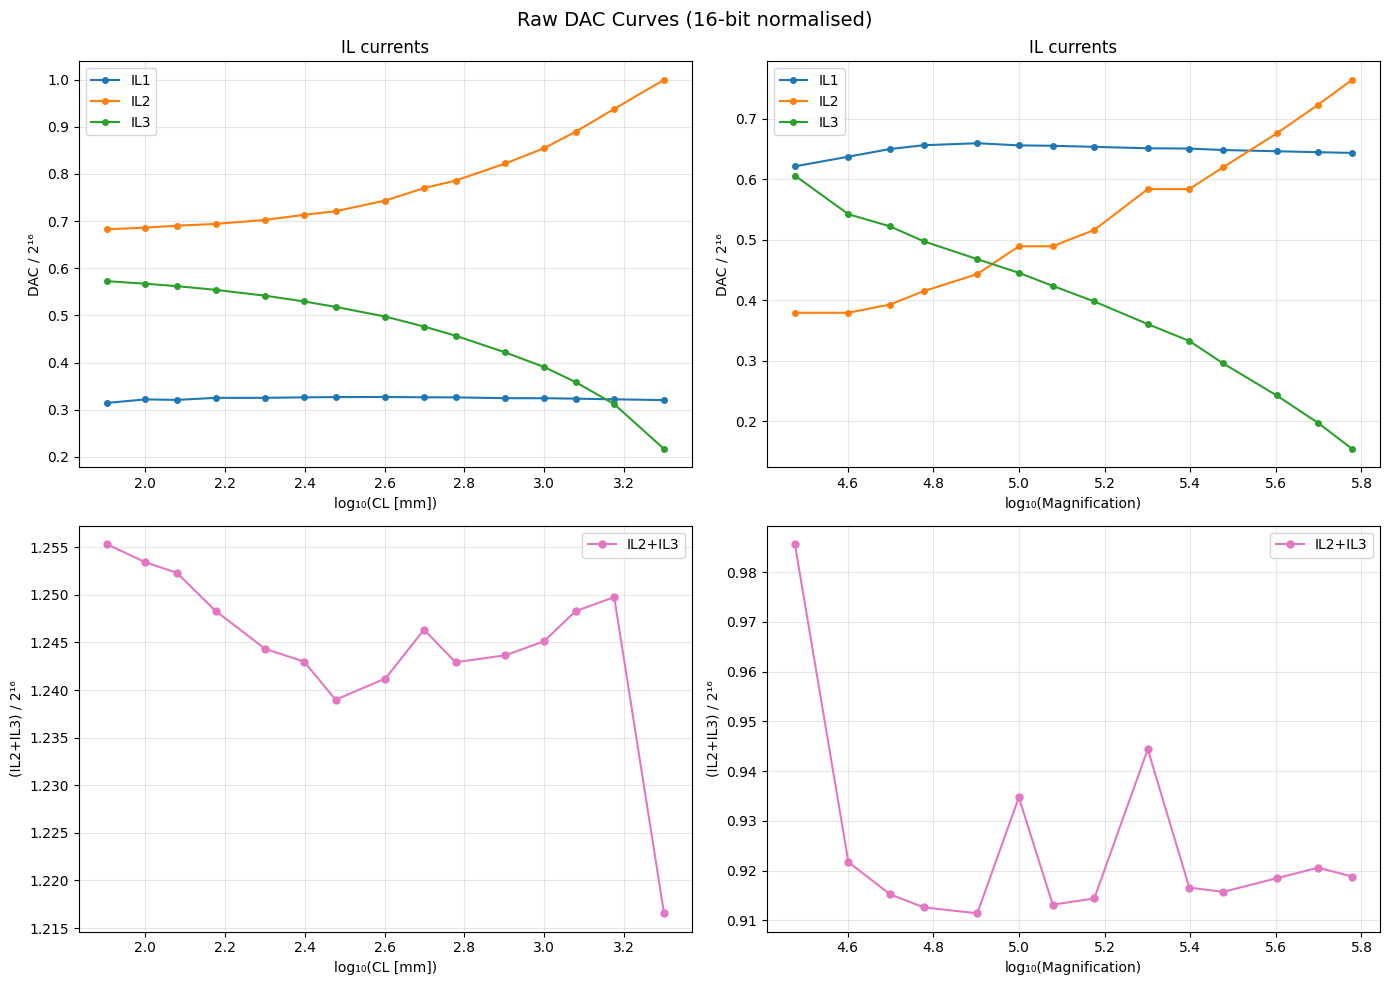

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Raw DAC hex tables (from microscope service menu) ====

CAMERA_LENGTH_RAW_DAC_HEX = {
    "80":   {"OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5078","IL2":"0xaec1","IL3":"0x929c","PL1":"0xfa00"},
    "100":  {"OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5265","IL2":"0xafa9","IL3":"0x9137","PL1":"0xfa00"},
    "120":  {"OM2":"0x0","IL1":"0x5221","IL2":"0xb0b6","IL3":"0x8fe1","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "150":  {"OM2":"0x0","IL1":"0x533e","IL2":"0xb1ad","IL3":"0x8de4","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "200":  {"IL2":"0xb3dc","IL3":"0x8aaf","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x533e"},
    "250":  {"OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5383","IL2":"0xb69f","IL3":"0x8796","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a"},
    "300":  {"OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x53a9","IL2":"0xb88f","IL3":"0x849f","PL1":"0xfa00","OLc":"0xb2fa"},
    "400":  {"IL1":"0x53b3","IL2":"0xbe63","IL3":"0x7f5d","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0"},
    "500":  {"OM2":"0x0","IL1":"0x538b","IL2":"0xc51d","IL3":"0x79f3","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "600":  {"OM2":"0x0","IL1":"0x5381","IL2":"0xc930","IL3":"0x7500","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "800":  {"IL1":"0x530b","IL2":"0xd280","IL3":"0x6be0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0"},
    "1000": {"IL2":"0xdac0","IL3":"0x6400","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x530b"},
    "1200": {"OM2":"0x0","IL1":"0x52cb","IL2":"0xe3c0","IL3":"0x5bd0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
    "1500": {"IL2":"0xf020","IL3":"0x4fd0","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800","OM2":"0x0","IL1":"0x5271"},
    "2000": {"OM2":"0x0","IL1":"0x5208","IL2":"0xfff0","IL3":"0x3780","PL1":"0xfa00","OLc":"0xb2fa","OLf":"0x981a","OLSuperFineValue":"0x800"},
}

IMAGING_MODE_RAW_DAC_HEX = {
    "30000":  {"IL1":"0x9f22","IL2":"0x611e","IL3":"0x9b35","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "40000":  {"IL1":"0xa336","IL2":"0x611e","IL3":"0x8ad8","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "50000":  {"IL1":"0xa674","IL2":"0x6498","IL3":"0x85b7","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "60000":  {"IL1":"0xa810","IL2":"0x6a48","IL3":"0x7f59","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "80000":  {"IL1":"0xa8ea","IL2":"0x7182","IL3":"0x77d2","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "100000": {"IL1":"0xa800","IL2":"0x7d46","IL3":"0x7205","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "120000": {"IL1":"0xa7d4","IL2":"0x7d46","IL3":"0x6c7f","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "150000": {"IL1":"0xa761","IL2":"0x8431","IL3":"0x65e6","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "200000": {"IL1":"0xa6c5","IL2":"0x957b","IL3":"0x5c4a","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "250000": {"IL1":"0xa6a8","IL2":"0x957b","IL3":"0x552b","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "300000": {"IL1":"0xa608","IL2":"0x9ec6","IL3":"0x4ba8","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "400000": {"IL1":"0xa584","IL2":"0xad0c","IL3":"0x3e16","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "500000": {"IL1":"0xa51d","IL2":"0xb944","IL3":"0x3268","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
    "600000": {"IL1":"0xa4d0","IL2":"0xc3c7","IL3":"0x2771","OLf":"0x990a","OLc":"0xb2fa","PL1":"0xfa00"},
}

# ==== Parse hex -> numeric arrays ====

DAC_FULL_SCALE = float(2 ** 16)

def parse_hex_table(raw, primary_axis_name):
    primary_values = sorted(int(key) for key in raw)
    data = {
        primary_axis_name: np.array(primary_values, dtype=float),
        f"log_{primary_axis_name}": np.log10(primary_values),
    }
    for lens_name in next(iter(raw.values())):
        data[lens_name] = np.array(
            [int(raw[str(v)][lens_name], 16) for v in primary_values], dtype=float,
        )
    return data

def scale_to_full_dac(values):
    return np.asarray(values, dtype=float) / DAC_FULL_SCALE

camera_length_dac = parse_hex_table(CAMERA_LENGTH_RAW_DAC_HEX, "camera_length_mm")
imaging_mode_dac  = parse_hex_table(IMAGING_MODE_RAW_DAC_HEX, "magnification")

# ==== Physical constants ====

M_PROJ = -100.0         # projector magnification (sign = image inversion)
I_MAX  = 5.0            # DAC full-scale current [A]
N_TURNS = np.array([1000, 1000, 1000])   # winding turns per IL lens

# Larmor rotation constant Rc at 200 kV:  Rc = e*mu0 / (2*me*v_rel)
U_ACCEL = 200e3
_e, _me, _c = 1.602176634e-19, 9.1093837015e-31, 299792458.0
_mu0 = 1.25663706212e-6
_gamma = 1.0 + _e * U_ACCEL / (_me * _c**2)
_v = _c * np.sqrt(1.0 - 1.0 / _gamma**2)
RC = float(_e * _mu0 / (2.0 * _me * _v))
print(f"Rc at {U_ACCEL/1e3:.0f} kV = {RC:.6e} rad/AT")

# ==== Normalised DAC reference arrays ====

mags_ref = np.array(sorted(int(k) for k in IMAGING_MODE_RAW_DAC_HEX), dtype=float)
x1_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float) / 65535.0
x2_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float) / 65535.0
x3_ref = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float) / 65535.0

cl_ref    = np.asarray(camera_length_dac["camera_length_mm"], dtype=float)
x1_cl_ref = scale_to_full_dac(camera_length_dac["IL1"])
x2_cl_ref = scale_to_full_dac(camera_length_dac["IL2"])
x3_cl_ref = scale_to_full_dac(camera_length_dac["IL3"])

print(f"Imaging:  {len(mags_ref)} points,  mag {mags_ref.min():.0f}..{mags_ref.max():.0f}")
print(f"Camera:   {len(cl_ref)} points,  CL {cl_ref.min():.0f}..{cl_ref.max():.0f} mm")

# ==== Visualise raw DAC curves ====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (data, xk, xlabel) in enumerate([
    (camera_length_dac, "log_camera_length_mm", "log₁₀(CL [mm])"),
    (imaging_mode_dac,  "log_magnification",    "log₁₀(Magnification)"),
]):
    # Top row: IL1, IL2, IL3
    ax = axes[0, col]
    for lens, c in zip(["IL1","IL2","IL3"], ["C0","C1","C2"]):
        ax.plot(data[xk], scale_to_full_dac(data[lens]), "o-", label=lens, color=c, ms=4)
    ax.set_ylabel("DAC / 2¹⁶"); ax.set_title(f"IL currents"); ax.legend(); ax.grid(True, alpha=0.3)

    # Bottom row: zoom-pair sum IL2+IL3
    ax = axes[1, col]
    ax.plot(data[xk], scale_to_full_dac(data["IL2"] + data["IL3"]), "o-", color="C6", ms=5, label="IL2+IL3")
    ax.set_ylabel("(IL2+IL3) / 2¹⁶"); ax.set_xlabel(xlabel); ax.legend(); ax.grid(True, alpha=0.3)

axes[0, 0].set_xlabel("log₁₀(CL [mm])"); axes[0, 1].set_xlabel("log₁₀(Magnification)")
fig.suptitle("Raw DAC Curves (16-bit normalised)", fontsize=14)
fig.tight_layout()
plt.show()

## Analytical solver

### Magnetic lens optics recap

The optical power (inverse focal length) of a magnetic round lens is

$$\phi \;=\; \frac{e}{8\,m_e\,U^*}\;\int_{-\infty}^{\infty} B_z^2(z)\,dz$$

where $U^* = U(1 + eU/2m_ec^2)$ is the relativistic accelerating potential.
Since $B_z \propto NI$, we get $\phi \propto (NI)^2$ with a proportionality
constant that depends only on **geometry** (bore, gap, pole pieces):

$$\phi_k \;=\; \underbrace{\alpha_\text{geom,k}\, N_k^2\, I_\text{MAX}^2}_{\displaystyle \alpha_k}\; x_k^2$$

The code fits the lumped $\alpha_k$ for each lens.  If the three IL lenses
share the same bore/gap design, their $\alpha_k$ differ only through winding
turns: $N_k/N_1 = \sqrt{\alpha_k/\alpha_1}$.  This is tested as a diagnostic
after fitting.

### Transfer-matrix polynomials $A$ and $B$

Each thin lens and drift is a $2{\times}2$ matrix:

$$P(d) = \begin{pmatrix}1 & d \\ 0 & 1\end{pmatrix}, \qquad
L(\phi) = \begin{pmatrix}1 & 0 \\ -\phi & 1\end{pmatrix}$$

The full IL transfer matrix is their product:

$$M = P(d_4)\, L(\phi_3)\, P(d_3)\, L(\phi_2)\, P(d_2)\, L(\phi_1)\, P(d_1)$$

Multiplying out, $A = M_{00}$ and $B = M_{01}$ are both **multilinear** in
$(\phi_1, \phi_2, \phi_3)$ — each variable appears at most to first power.
Written out in full:

$$A = 1 - (d_2{+}d_3{+}d_4)\,\phi_1 - (d_3{+}d_4)\,\phi_2 - d_4\,\phi_3$$
$$\quad + d_2(d_3{+}d_4)\,\phi_1\phi_2 + (d_2{+}d_3)d_4\,\phi_1\phi_3 + d_3 d_4\,\phi_2\phi_3 - d_2 d_3 d_4\,\phi_1\phi_2\phi_3$$

$$B = (d_1{+}d_2{+}d_3{+}d_4) - d_1(d_2{+}d_3{+}d_4)\,\phi_1 - (d_1{+}d_2)(d_3{+}d_4)\,\phi_2 - (d_1{+}d_2{+}d_3)d_4\,\phi_3$$
$$\quad + d_1 d_2(d_3{+}d_4)\,\phi_1\phi_2 + d_1(d_2{+}d_3)d_4\,\phi_1\phi_3 + (d_1{+}d_2)d_3 d_4\,\phi_2\phi_3 - d_1 d_2 d_3 d_4\,\phi_1\phi_2\phi_3$$

### The imaging condition

For the IL system to produce a focused image, we need two things simultaneously:

- **Magnification:** $A = m$ (the desired IL magnification)
- **Focus:** $B = 0$ (rays from a point reconverge to a point)

The key insight of this solver is that both conditions can be **enforced
analytically** — no numerical root-finding is needed for the optics.

### Eliminating $\phi_1$: why $B = 0$ and $A = m$ collapse to one equation

Isolate lens 1 by defining $M_\text{rest} = P(d_4)\,L(\phi_3)\,P(d_3)\,L(\phi_2)\,P(d_2)$.
Then $M = M_\text{rest} \, L(\phi_1) \, P(d_1)$ and working out the top row:

$$A = a - b\,\phi_1, \qquad B = a\,d_1 + b\,(1 - d_1\,\phi_1)$$

where $a = M_\text{rest}[0,0]$ and $b = M_\text{rest}[0,1]$ depend only on
$(\phi_2, \phi_3)$.  Substituting $\phi_1 = (a{-}m)/b$ from $A = m$ into
$B = 0$:

$$a\,d_1 + b - d_1(a-m) = 0 \quad\Longrightarrow\quad b + d_1\,m = 0$$

The $\phi_1$ drops out entirely.  The two constraints reduce to:

$$\boxed{M_\text{rest}[0,1] = -d_1\,m}$$

### Closed-form solutions for $\phi_2$ and $\phi_1$

$M_\text{rest}[0,1]$ is multilinear in $(\phi_2, \phi_3)$, so the equation
above is **linear in $\phi_2$** for any given $\phi_3$:

$$\phi_2 = \frac{d_1\,m + (d_2{+}d_3{+}d_4) - (d_2{+}d_3)\,d_4\,\phi_3}
               {d_2\bigl[(d_3{+}d_4) - d_3\,d_4\,\phi_3\bigr]}
\qquad \text{(one division)}$$

With $\phi_2$ and $\phi_3$ now both known, $A = m$ is linear in $\phi_1$:

$$\phi_1 = \frac{m - A^{(0)}}{A^{(1)}}
\qquad \text{(one more division)}$$

### How the fit works (inverse step)

We know the **data**: for each magnification or camera-length setting, the
microscope DAC tables give normalised currents $(x_1, x_2, x_3)$.  We know
the **targets**: $A = m$ and $B = 0$.

Rather than fitting $A$ and $B$ residuals separately, we **enforce $B = 0$ and
$A = m$ exactly** using the closed-form solutions above.  For each data point:

1. Set $\phi_3 = \alpha_3\, x_{3,\text{data}}^2$ from the measured IL3 current
2. Compute $\phi_2^* = \texttt{phi2\_exact}(\phi_3, m, \mathbf{d})$ — the
   unique $\phi_2$ satisfying $B{=}0$ and $A{=}m$
3. Compute $\phi_1^* = \texttt{phi1\_exact}(\phi_2^*, \phi_3, m, \mathbf{d})$
   — the unique $\phi_1$ giving $A{=}m$
4. Convert back: $x_k^{\text{implied}} = \sqrt{\phi_k^*/\alpha_k}$
5. Residual: $x_k^{\text{implied}} - x_{k,\text{data}}$

By construction, every operating point has **exactly** $B = 0$ and $A = m$.
The residuals measure how well the power law $\phi_k = \alpha_k x_k^2$
reproduces the required lens powers.  We minimise these with
`scipy.optimize.least_squares`, aided by soft CAD priors on the distances.

### How the curves are generated (forward step)

Once the 9 parameters are known, we reverse the problem — given a desired $m$,
find $(x_1, x_2, x_3)$:

1. **Pick** a trial $x_3$ (i.e. $\phi_3 = \alpha_3 x_3^2$)
2. **Solve** for $\phi_2$ from $B{=}0, A{=}m$ (one division)
3. **Solve** for $\phi_1$ from $A = m$ (one division)
4. **Convert** back: $x_k = \sqrt{\phi_k / \alpha_k}$, reject if any $x_k > 1$

One degree of freedom remains ($x_3$).  It is fixed by the **rotation
constraint**: $x_1 + x_2 + x_3 = r$ (constant), solved as a 1-D root find.

### Fit parameters (9 total)

| Parameter | Description |
|-----------|-------------|
| $d_1^{\text{img}},\; d_1^{\text{cam}}$ | Object distance (differs between modes) |
| $d_2,\; d_4$ | Shared inter-lens distances |
| $\alpha_1,\;\alpha_2,\;\alpha_3$ | Current-to-power constants (absorb geometry + turns + $I_\text{MAX}$) |
| $s_\text{img},\; s_\text{cam}$ | Scale factors (absorb $M_\text{obj} M_\text{proj}$ and $f_\text{obj} M_\text{proj}$) |

Rotation invariant  r = x1+x2+x3:
  Imaging: 1.5730 +/- 0.0138
  Camera:  1.5683 +/- 0.0087

CAD priors  (d3=62.5 mm):
  d2=1.233  d4=0.833  d1_img=0.200  d1_cam=3.200

Fitting: 4 signs × 13 starts × 3 img-weights × 2 methods ...
Done in 21.0s  |  signs=(+1,+1)  w_img=1.0  cost=0.456403

Distances (d3=1=62.5 mm):
  d1_img  = 0.2112  (CAD 0.200, +0.4σ)
  d1_cam  = 2.1723  (CAD 3.200, -2.1σ)
  d2      = 1.1870  (CAD 1.233, -0.3σ)
  d4      = 0.8323  (CAD 0.833, -0.0σ)
  alpha   = [13.1786, 15.6901, 6.6768]
  s_img   = 1.1725e-04   →  M_obj·M_proj = 8529.0
  s_cam   = 5.8749e-03   →  f_obj = 1.702 mm

Implied turns ratios  γ_k = N_k/N_1 = √(α_k/α_1):
  γ = [1.0000, 1.0911, 0.7118]
  If N_1=1000:  N = [1000, 1091, 712]

Larmor rotation  θ = Rc·I_MAX·Σ(Nk·xk)   (I_MAX=5.0 A, N=[1000,1000,1000]):
  Imaging: 238.9° ± 2.1°
  Camera:  238.2° ± 1.3°
  (with implied N):  Imaging 229.1°  Camera 228.6°

Rotation-invariant quality  (lower CV% = more constant):
  Equal wt:   img CV=0.88%  cam CV=0.55

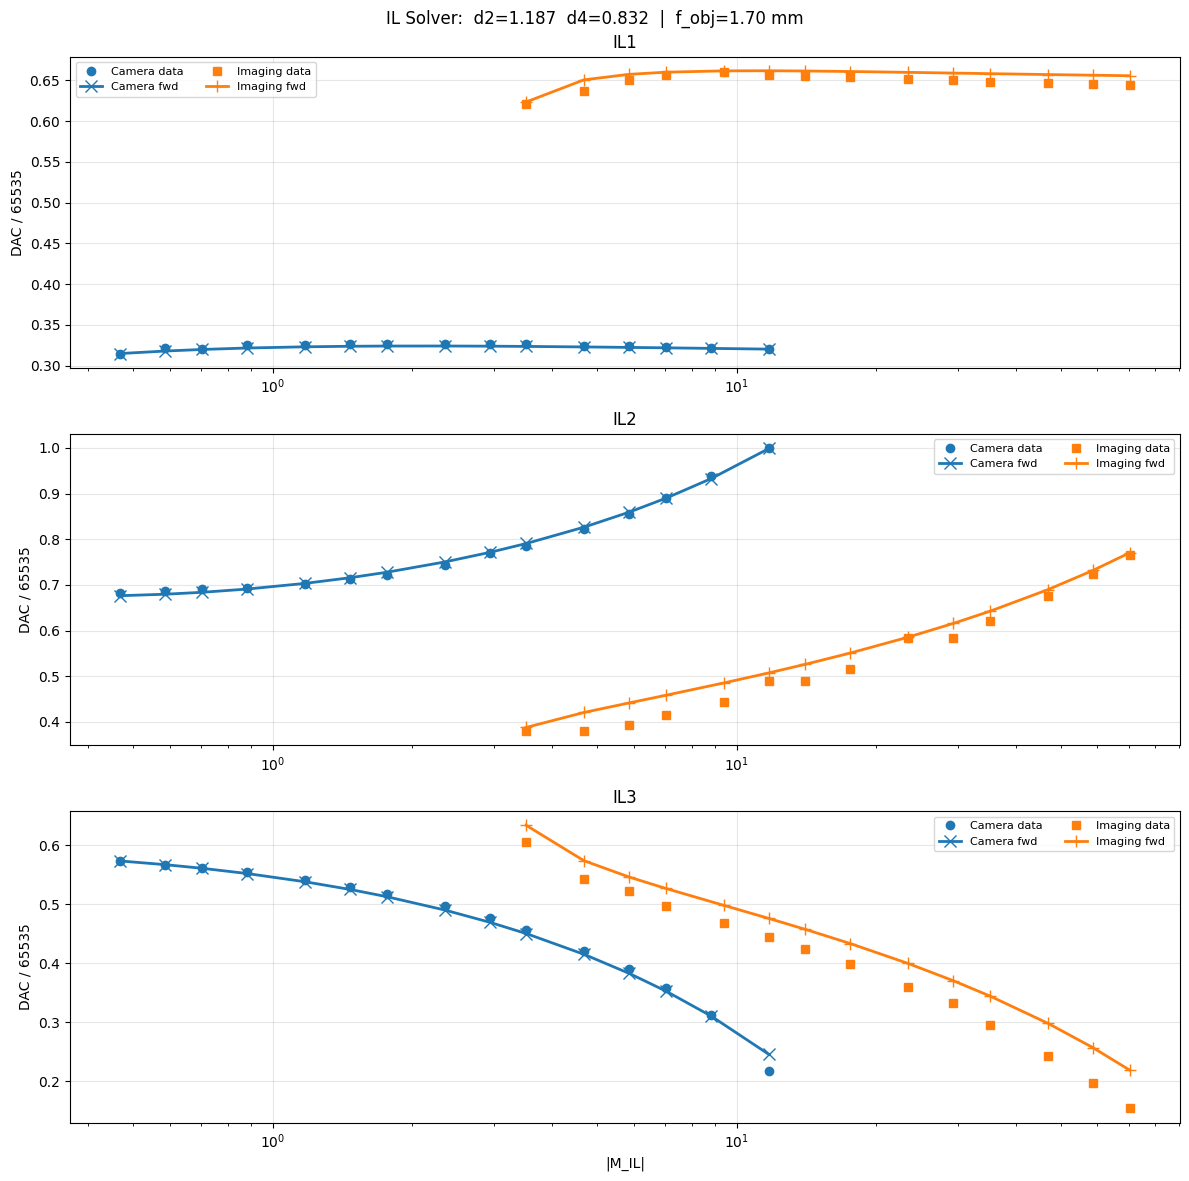


RMSE (forward vs data):
  IL1: img=0.00835  cam=0.00222
  IL2: img=0.02956  cam=0.00466
  IL3: img=0.04127  cam=0.00884
  Overall: 0.02107  (29/29 points)


In [ ]:
from scipy.optimize import least_squares, brentq
import time

# ── Transfer-matrix polynomials A = M[0,0], B = M[0,1] ──────────────

def A_poly(d, p):
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return (1.0
            - (d2+d3+d4)*p1 - (d3+d4)*p2 - d4*p3
            + d2*(d3+d4)*p1*p2 + (d2+d3)*d4*p1*p3 + d3*d4*p2*p3
            - d2*d3*d4*p1*p2*p3)

def B_poly(d, p):
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return ((d1+d2+d3+d4)
            - d1*(d2+d3+d4)*p1 - (d1+d2)*(d3+d4)*p2 - (d1+d2+d3)*d4*p3
            + d1*d2*(d3+d4)*p1*p2 + d1*(d2+d3)*d4*p1*p3 + (d1+d2)*d3*d4*p2*p3
            - d1*d2*d3*d4*p1*p2*p3)

# ── Rotation invariant from data ─────────────────────────────────────

w = np.ones(3)                            # equal turns → equal weights
r_img_vals = x1_ref + x2_ref + x3_ref
r_cam_vals = x1_cl_ref + x2_cl_ref + x3_cl_ref
print(f"Rotation invariant  r = x1+x2+x3:")
print(f"  Imaging: {np.mean(r_img_vals):.4f} +/- {np.std(r_img_vals):.4f}")
print(f"  Camera:  {np.mean(r_cam_vals):.4f} +/- {np.std(r_cam_vals):.4f}")

# ── CAD priors (from pixel measurements in measure_microscope_geometry) ──
#    Scale bar: 96 px = 200 mm;  d3 = IL2→IL3 = 30 px → reference length
_px_mm = 200.0 / (624 - 528)
_d3_mm = (739 - 709) * _px_mm
CAD_D2  = (709 - 672) * _px_mm / _d3_mm   # IL1→IL2
CAD_D4  = (764 - 739) * _px_mm / _d3_mm   # IL3→PL1
CAD_D1I = (672 - 666) * _px_mm / _d3_mm   # SAA→IL1  (imaging object)
CAD_D1C = (672 - 576) * _px_mm / _d3_mm   # ObjPost→IL1  (diffraction object)
CAD_SIGMA = 0.15   # fractional 1-sigma (~2-3 px uncertainty)
W_CAD   = 1.0      # CAD prior weight

# f_obj soft prior: |M_proj|·f_obj ≈ 1/s_cam, expect f_obj ∈ [1, 4] mm
F_OBJ_MIN_MM, F_OBJ_MAX_MM = 1.0, 4.0
W_FOBJ = 0.1
W_IL2  = 1.0       # IL2 emphasis in forward branch selection

print(f"\nCAD priors  (d3={_d3_mm:.1f} mm):")
print(f"  d2={CAD_D2:.3f}  d4={CAD_D4:.3f}  d1_img={CAD_D1I:.3f}  d1_cam={CAD_D1C:.3f}")

# ── Closed-form B=0 + A=m solutions ─────────────────────────────────

def phi2_exact(phi3, m, d):
    """φ₂ from the combined B=0, A=m constraint (closed form)."""
    d1, d2, d3, d4 = d
    num = d1*m + (d2+d3+d4) - (d2+d3)*d4*phi3
    den = d2*((d3+d4) - d3*d4*phi3)
    return num / den if abs(den) > 1e-30 else np.nan

def phi1_exact(phi2, phi3, m, d):
    """φ₁ from A=m with φ₂, φ₃ known (closed form)."""
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3+d4)*phi2 - d4*phi3 + d3*d4*phi2*phi3
    A1 = -(d2+d3+d4) + d2*(d3+d4)*phi2 + (d2+d3)*d4*phi3 - d2*d3*d4*phi2*phi3
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan

# ── Inverse fit (B=0 constrained) ────────────────────────────────────
# 9 parameters: [d1_img, d1_cam, d2, d4,
#                log(α1), log(α2), log(α3), log(s_img), log(s_cam)]

x_img = np.array([x1_ref, x2_ref, x3_ref])
x_cam = np.array([x1_cl_ref, x2_cl_ref, x3_cl_ref])

def make_residual_fn(si, sc, w_img=1.0):
    """Residuals with B=0 and A=m enforced analytically.

    For each data point, the closed-form solutions give the exact (φ1*, φ2*)
    that satisfy B=0 and A=m.  The residuals are x_implied - x_data.
    """
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i = np.array([d1i, d2, 1.0, d4])
        d_c = np.array([d1c, d2, 1.0, d4])
        res = []
        # Imaging mode
        for j in range(len(mags_ref)):
            m = si * s_i * mags_ref[j]
            p3 = alpha[2] * x_img[2, j]**2
            p2star = phi2_exact(p3, m, d_i)
            if (not np.isfinite(p2star)) or p2star <= 0:
                res.extend([w_img * 1.0, w_img * 1.0])
                continue
            p1star = phi1_exact(p2star, p3, m, d_i)
            if (not np.isfinite(p1star)) or p1star <= 0:
                res.extend([w_img * 1.0, w_img * 1.0])
                continue
            x1_imp = np.sqrt(p1star / alpha[0])
            x2_imp = np.sqrt(p2star / alpha[1])
            res.append(w_img * (x1_imp - x_img[0, j]))
            res.append(w_img * (x2_imp - x_img[1, j]))
        # Camera mode
        for j in range(len(cl_ref)):
            m = sc * s_c * cl_ref[j]
            p3 = alpha[2] * x_cam[2, j]**2
            p2star = phi2_exact(p3, m, d_c)
            if (not np.isfinite(p2star)) or p2star <= 0:
                res.extend([1.0, 1.0])
                continue
            p1star = phi1_exact(p2star, p3, m, d_c)
            if (not np.isfinite(p1star)) or p1star <= 0:
                res.extend([1.0, 1.0])
                continue
            x1_imp = np.sqrt(p1star / alpha[0])
            x2_imp = np.sqrt(p2star / alpha[1])
            res.append(x1_imp - x_cam[0, j])
            res.append(x2_imp - x_cam[1, j])
        # CAD distance priors
        res.append(W_CAD       * (d2  - CAD_D2)  / (CAD_SIGMA * CAD_D2))
        res.append(W_CAD       * (d4  - CAD_D4)  / (CAD_SIGMA * CAD_D4))
        res.append(W_CAD       * (d1i - CAD_D1I) / (CAD_SIGMA * CAD_D1I))
        res.append(W_CAD / 3.0 * (d1c - CAD_D1C) / (CAD_SIGMA * CAD_D1C))
        # f_obj soft prior
        f_obj_mm = 1.0 / (abs(M_PROJ) * s_c)
        res.append(W_FOBJ * max(0.0, F_OBJ_MIN_MM - f_obj_mm))
        res.append(W_FOBJ * max(0.0, f_obj_mm - F_OBJ_MAX_MM))
        return np.array(res)
    return fn

lb = np.array([0.05, 0.10, 0.60, 0.40,
               np.log(0.01), np.log(0.01), np.log(0.01), np.log(1e-7), np.log(1e-7)])
ub = np.array([0.80, 7.0,  2.20, 1.50,
               np.log(1000), np.log(1000), np.log(1000), np.log(1.0), np.log(1.0)])

_p_cad = [CAD_D1I, CAD_D1C, CAD_D2, CAD_D4]
_ls0 = [np.log(1/3000), np.log(1/230)]
_ls1 = [np.log(1/6000), np.log(1/500)]
_ls2 = [np.log(1/1500), np.log(1/100)]

init_guesses = [
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls0,
    _p_cad + [np.log(3),   np.log(3.5), np.log(2.5)] + _ls0,
    _p_cad + [np.log(20),  np.log(20),  np.log(10)]  + _ls0,
    _p_cad + [np.log(5),   np.log(7),   np.log(4)]   + _ls0,
    _p_cad + [np.log(30),  np.log(40),  np.log(15)]  + _ls0,
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls1,
    _p_cad + [np.log(10),  np.log(10),  np.log(5)]   + _ls2,
    [0.16, 0.26, 0.84, 0.79, np.log(3),  np.log(3.5), np.log(2.5)] + _ls0,
    [0.10, 0.15, 0.80, 0.70, np.log(10), np.log(10),  np.log(5)]   + _ls0,
    [0.20, 0.50, 1.20, 0.80, np.log(15), np.log(18),  np.log(8)]   + _ls0,
    [0.05, 0.10, 1.00, 1.00, np.log(20), np.log(20),  np.log(10)]  + _ls0,
    [0.30, 1.00, 1.50, 1.00, np.log(1),  np.log(1),   np.log(1)]   + _ls0,
    [0.10, 0.50, 0.80, 0.60, np.log(50), np.log(50),  np.log(30)]  + _ls1,
]

# Sweep over sign combos, initial guesses, imaging weights, and two methods
W_IMG_VALS = [1.0, 1.5, 2.0]

print(f"\nFitting (B=0 constrained): 4 signs × {len(init_guesses)} starts × {len(W_IMG_VALS)} img-weights × 2 methods ...")
t0 = time.perf_counter()
best_result, best_cost, best_signs, best_wimg = None, np.inf, None, None

for si in [+1, -1]:
    for sc in [+1, -1]:
        for w_img in W_IMG_VALS:
            fn = make_residual_fn(si, sc, w_img=w_img)
            for p0 in init_guesses:
                for meth in ['trf', 'dogbox']:
                    try:
                        res = least_squares(fn, p0, bounds=(lb, ub), method=meth,
                                            max_nfev=20000, verbose=0, diff_step=0.001)
                        if res.cost < best_cost:
                            best_cost, best_result, best_signs = res.cost, res, (si, sc)
                            best_wimg = w_img
                    except Exception:
                        pass

# Warm-start: refine the best solution with very tight tolerances
if best_result is not None:
    for w_img in W_IMG_VALS:
        fn = make_residual_fn(*best_signs, w_img=w_img)
        for meth in ['trf', 'dogbox']:
            try:
                res = least_squares(fn, best_result.x, bounds=(lb, ub), method=meth,
                                    max_nfev=100000, verbose=0, diff_step=1e-4,
                                    ftol=1e-15, xtol=1e-15, gtol=1e-15)
                if res.cost < best_cost:
                    best_cost, best_result = res.cost, res
                    best_wimg = w_img
            except Exception:
                pass

si_best, sc_best = best_signs
print(f"Done in {time.perf_counter()-t0:.1f}s  |  signs=({si_best:+d},{sc_best:+d})  w_img={best_wimg}  cost={best_cost:.6f}")

# Extract fitted parameters
d1i_f, d1c_f, d2_f, d4_f = best_result.x[:4]
alpha_f = np.exp(best_result.x[4:7])
s_img_f, s_cam_f = np.exp(best_result.x[7]), np.exp(best_result.x[8])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])
m_img = s_img_f * mags_ref
m_cam = s_cam_f * cl_ref

f_obj_fit_mm = 1.0 / (abs(M_PROJ) * s_cam_f)

print(f"\nDistances (d3=1={_d3_mm:.1f} mm):")
for nm, fit, cad in [('d1_img', d1i_f, CAD_D1I), ('d1_cam', d1c_f, CAD_D1C),
                     ('d2', d2_f, CAD_D2), ('d4', d4_f, CAD_D4)]:
    print(f"  {nm:7s} = {fit:.4f}  (CAD {cad:.3f}, {(fit-cad)/(CAD_SIGMA*cad):+.1f}σ)")
print(f"  alpha   = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]")
print(f"  s_img   = {s_img_f:.4e}   →  M_obj·M_proj = {1/s_img_f:.1f}")
print(f"  s_cam   = {s_cam_f:.4e}   →  f_obj = {f_obj_fit_mm:.3f} mm")

# ── Implied turns ratios (assumes identical lens geometry) ───────────
gamma = np.sqrt(alpha_f / alpha_f[0])
print(f"\nImplied turns ratios  γ_k = N_k/N_1 = √(α_k/α_1):")
print(f"  γ = [{gamma[0]:.4f}, {gamma[1]:.4f}, {gamma[2]:.4f}]")
print(f"  If N_1=1000:  N = [{1000*gamma[0]:.0f}, {1000*gamma[1]:.0f}, {1000*gamma[2]:.0f}]")

# ── Larmor rotation diagnostic ───────────────────────────────────────

theta_img = np.degrees(RC * I_MAX * (N_TURNS @ x_img))
theta_cam = np.degrees(RC * I_MAX * (N_TURNS @ x_cam))
print(f"\nLarmor rotation  θ = Rc·I_MAX·Σ(Nk·xk):")
print(f"  Imaging: {np.mean(theta_img):.1f}° ± {np.std(theta_img):.1f}°")
print(f"  Camera:  {np.mean(theta_cam):.1f}° ± {np.std(theta_cam):.1f}°")

theta_img_gamma = np.degrees(RC * I_MAX * 1000 * (gamma @ x_img))
theta_cam_gamma = np.degrees(RC * I_MAX * 1000 * (gamma @ x_cam))
print(f"  (with implied N):  Imaging {np.mean(theta_img_gamma):.1f}°  Camera {np.mean(theta_cam_gamma):.1f}°")

r_img_eq = x1_ref + x2_ref + x3_ref
r_cam_eq = x1_cl_ref + x2_cl_ref + x3_cl_ref
r_img_gw = gamma[0]*x1_ref + gamma[1]*x2_ref + gamma[2]*x3_ref
r_cam_gw = gamma[0]*x1_cl_ref + gamma[1]*x2_cl_ref + gamma[2]*x3_cl_ref
print(f"\nRotation-invariant quality  (lower CV% = more constant):")
print(f"  Equal wt:   img CV={np.std(r_img_eq)/np.mean(r_img_eq)*100:.2f}%  cam CV={np.std(r_cam_eq)/np.mean(r_cam_eq)*100:.2f}%")
print(f"  γ-weighted: img CV={np.std(r_img_gw)/np.mean(r_img_gw)*100:.2f}%  cam CV={np.std(r_cam_gw)/np.mean(r_cam_gw)*100:.2f}%")

# ── Forward solver: exact B=0 elimination + rotation root find ───────

def find_all_roots(m, d, alpha, r_target, x3_grid):
    """Find all (x1,x2,x3) satisfying A=m, B=0, x1+x2+x3=r_target."""
    p3 = alpha[2] * x3_grid**2
    d1, d2, d3_, d4 = d
    num2 = d1*m + (d2+d3_+d4) - (d2+d3_)*d4*p3
    den2 = d2*((d3_+d4) - d3_*d4*p3)
    p2 = np.where(np.abs(den2) > 1e-30, num2/den2, np.nan)
    A0 = 1 - (d3_+d4)*p2 - d4*p3 + d3_*d4*p2*p3
    A1 = -(d2+d3_+d4) + d2*(d3_+d4)*p2 + (d2+d3_)*d4*p3 - d2*d3_*d4*p2*p3
    p1 = np.where(np.abs(A1) > 1e-30, (m - A0)/A1, np.nan)
    ok = np.isfinite(p1) & np.isfinite(p2) & (p1 > 0) & (p2 > 0)
    x1 = np.where(ok, np.sqrt(np.maximum(p1, 0)/alpha[0]), np.nan)
    x2 = np.where(ok, np.sqrt(np.maximum(p2, 0)/alpha[1]), np.nan)
    ok2 = ok & np.isfinite(x1) & np.isfinite(x2) & (x1 < 1.05) & (x2 < 1.05)
    rot = np.where(ok2, w[0]*x1 + w[1]*x2 + w[2]*x3_grid - r_target, np.nan)

    def rot_scalar(x3):
        _p3 = alpha[2]*x3**2
        _p2 = phi2_exact(_p3, m, d)
        if (not np.isfinite(_p2)) or _p2 <= 0: return np.nan
        _p1 = phi1_exact(_p2, _p3, m, d)
        if (not np.isfinite(_p1)) or _p1 <= 0: return np.nan
        _x1, _x2 = np.sqrt(_p1/alpha[0]), np.sqrt(_p2/alpha[1])
        if _x1 > 1.05 or _x2 > 1.05: return np.nan
        return w[0]*_x1 + w[1]*_x2 + w[2]*x3 - r_target

    roots = []
    for j in range(len(rot) - 1):
        if np.isfinite(rot[j]) and np.isfinite(rot[j+1]) and rot[j]*rot[j+1] < 0:
            try:
                x3s = brentq(rot_scalar, x3_grid[j], x3_grid[j+1], xtol=1e-12)
            except (ValueError, RuntimeError):
                continue
            p3s = alpha[2]*x3s**2
            p2s = phi2_exact(p3s, m, d)
            p1s = phi1_exact(p2s, p3s, m, d)
            if p1s > 0 and p2s > 0:
                x1s, x2s = np.sqrt(p1s/alpha[0]), np.sqrt(p2s/alpha[1])
                if all(0.005 < v < 1.05 for v in [x1s, x2s, x3s]):
                    roots.append((x1s, x2s, x3s))
    return roots

def predict_fwd(m_arr, d, alpha, r_target, x_ref_data=None):
    """Forward-predict DAC values with branch continuity."""
    n = len(m_arr)
    out = np.full((3, n), np.nan)
    g0 = np.linspace(0.005, 1.0, 3000)
    prev_x3 = None
    for i, m_val in enumerate(m_arr):
        if prev_x3 is not None:
            lo, hi = max(0.005, prev_x3-0.3), min(1.0, prev_x3+0.3)
            grid = np.sort(np.unique(np.concatenate([np.linspace(lo, hi, 1500), g0[::3]])))
        else:
            grid = g0
        roots = find_all_roots(m_val, d, alpha, r_target, grid)
        if not roots:
            roots = find_all_roots(m_val, d, alpha, r_target, g0)
        if roots:
            if prev_x3 is not None:
                best = min(roots, key=lambda r: abs(r[2] - prev_x3))
            elif x_ref_data is not None:
                best = min(roots, key=lambda r: abs(r[2] - x_ref_data[2, i]))
            else:
                best = roots[0]
            out[:, i] = best
            prev_x3 = best[2]
    return out

def choose_r_target(m_arr, d, alpha, r_vals, sign, x_ref_data, force_first=False):
    """Pick r_target that gives best forward match to reference data."""
    r_lo, r_hi = float(np.min(r_vals)) - 0.15, float(np.max(r_vals)) + 0.15
    r_grid = np.linspace(r_lo, r_hi, 401)
    r_mean = float(np.mean(r_vals))
    best_score, best_r, best_pred = None, None, None
    for r_try in r_grid:
        pred = predict_fwd(sign * m_arr, d, alpha, float(r_try), x_ref_data=x_ref_data)
        solved = int(np.sum(np.isfinite(pred[0])))
        miss = len(m_arr) - solved
        first_ok = bool(np.isfinite(pred[0, 0]))
        mask = np.isfinite(pred)
        if np.any(mask):
            w_err = np.ones_like(x_ref_data)
            w_err[1, :] = W_IL2
            err2 = (pred - x_ref_data)**2
            rmse = float(np.sqrt(np.sum(w_err[mask] * err2[mask]) / np.sum(w_err[mask])))
        else:
            rmse = 1e9
        first_pen = 0 if (first_ok or not force_first) else 1
        score = (first_pen, miss, rmse, abs(float(r_try) - r_mean))
        if best_score is None or score < best_score:
            best_score, best_r, best_pred = score, float(r_try), pred
    return best_r, best_pred, best_score

# ── Run forward prediction ───────────────────────────────────────────

r_img0, pi_f, score_img = choose_r_target(m_img, d_img_f, alpha_f, r_img_vals, si_best, x_img, force_first=False)
r_cam0, pc_f, score_cam = choose_r_target(m_cam, d_cam_f, alpha_f, r_cam_vals, sc_best, x_cam, force_first=False)

n_img_ok = np.sum(np.isfinite(pi_f[0]))
n_cam_ok = np.sum(np.isfinite(pc_f[0]))
print(f"\nForward prediction:")
print(f"  r_img = {r_img0:.4f}  |  r_cam = {r_cam0:.4f}")
print(f"  Solved: imaging {n_img_ok}/{len(m_img)}, camera {n_cam_ok}/{len(m_cam)}")

# ── Plot: data vs forward prediction ─────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle(f'IL Solver (B=0 constrained):  d2={d2_f:.3f}  d4={d4_f:.3f}  |  f_obj={f_obj_fit_mm:.2f} mm', fontsize=12)

lenses = [
    ('IL1', x1_ref, pi_f[0], x1_cl_ref, pc_f[0]),
    ('IL2', x2_ref, pi_f[1], x2_cl_ref, pc_f[1]),
    ('IL3', x3_ref, pi_f[2], x3_cl_ref, pc_f[2]),
]
for ax, (nm, yi_r, yi_f, yc_r, yc_f) in zip(axes, lenses):
    ax.plot(m_cam, yc_r, 'o', color='C0', ms=6, label='Camera data')
    mc = np.isfinite(yc_f)
    if np.any(mc):
        ax.plot(m_cam[mc], yc_f[mc], 'x-', color='C0', lw=2, ms=8, label='Camera fwd')
    ax.plot(m_img, yi_r, 's', color='C1', ms=6, label='Imaging data')
    mi = np.isfinite(yi_f)
    if np.any(mi):
        ax.plot(m_img[mi], yi_f[mi], '+-', color='C1', lw=2, ms=8, label='Imaging fwd')
    ax.set_xscale('log'); ax.set_ylabel('DAC / 65535'); ax.set_title(nm)
    ax.grid(True, alpha=0.3); ax.legend(ncol=2, fontsize=8)
axes[-1].set_xlabel('|M_IL|')
plt.tight_layout(); plt.show()

# ── RMSE summary ─────────────────────────────────────────────────────

print("\nRMSE (forward vs data):")
all_errs = []
for nm, yr, yf, ycr, ycf in lenses:
    mi, mc = np.isfinite(yf), np.isfinite(ycf)
    ri = np.sqrt(np.mean((yf[mi]-yr[mi])**2)) if np.any(mi) else np.nan
    rc = np.sqrt(np.mean((ycf[mc]-ycr[mc])**2)) if np.any(mc) else np.nan
    print(f"  {nm}: img={ri:.5f}  cam={rc:.5f}")
    if np.any(mi): all_errs.append((yf[mi]-yr[mi])**2)
    if np.any(mc): all_errs.append((ycf[mc]-ycr[mc])**2)
if all_errs:
    print(f"  Overall: {np.sqrt(np.mean(np.concatenate(all_errs))):.5f}  ({n_img_ok+n_cam_ok}/{len(m_img)+len(m_cam)} points)")

In [41]:
# ── Real-valued distances and focal lengths ──────────────────────────
# All model distances are in units of d3.  Multiply by d3 (mm) to get mm.

D3_MM = _d3_mm  # d3 in mm (from CAD pixel measurement)

print(f"Reference length  d3 = {D3_MM:.1f} mm")
print(f"\n{'─'*70}")
print(f"Real distances (mm):")
print(f"  d1_img = {d1i_f * D3_MM:.1f} mm    d1_cam = {d1c_f * D3_MM:.1f} mm")
print(f"  d2     = {d2_f * D3_MM:.1f} mm    d3     = {D3_MM:.1f} mm")
print(f"  d4     = {d4_f * D3_MM:.1f} mm")
print(f"  Total column (img) = {(d1i_f + d2_f + 1.0 + d4_f) * D3_MM:.1f} mm")
print(f"  Total column (cam) = {(d1c_f + d2_f + 1.0 + d4_f) * D3_MM:.1f} mm")

# ── Focal lengths at every operating point ───────────────────────────
# φ_k = α_k x_k² is in units of 1/d3,  so  f_k = d3 / (α_k x_k²)  [mm]

print(f"\n{'─'*70}")
print(f"Focal lengths  f_k = d3 / (α_k · x_k²)  [mm]")
print(f"{'─'*70}")

print(f"\n{'Mag':>8s}  {'f1 (mm)':>9s}  {'f2 (mm)':>9s}  {'f3 (mm)':>9s}  "
      f"{'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 68)
for j in range(len(mags_ref)):
    phi = alpha_f * x_img[:, j]**2
    f = D3_MM / phi
    print(f"{mags_ref[j]:>8.0f}  {f[0]:>9.2f}  {f[1]:>9.2f}  {f[2]:>9.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

print(f"\n{'CL (mm)':>8s}  {'f1 (mm)':>9s}  {'f2 (mm)':>9s}  {'f3 (mm)':>9s}  "
      f"{'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 68)
for j in range(len(cl_ref)):
    phi = alpha_f * x_cam[:, j]**2
    f = D3_MM / phi
    print(f"{cl_ref[j]:>8.0f}  {f[0]:>9.2f}  {f[1]:>9.2f}  {f[2]:>9.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

# ── Peak power and minimum focal length (at x_k = 1) ────────────────
phi_max = alpha_f      # φ_k at x_k = 1 (full excitation)
f_min   = D3_MM / phi_max

print(f"\n{'─'*70}")
print(f"Peak excitation (x_k = 1):")
print(f"  φ_max  = [{phi_max[0]:.2f}, {phi_max[1]:.2f}, {phi_max[2]:.2f}]  (1/d3)")
print(f"  f_min  = [{f_min[0]:.2f}, {f_min[1]:.2f}, {f_min[2]:.2f}]  mm")

# ── Decomposition of α into geometry + turns + I_MAX ─────────────────
# α_k = α_geom,k · N_k² · I_MAX²   (units: 1/d3)
# α_geom,k = α_k / (N_k² I_MAX²)   (units: 1 / (d3 · A²))
# In SI:  α_geom,k^SI = α_k / (d3_m · N_k² · I_MAX²)  [1 / (m · A²)]

d3_m = D3_MM * 1e-3
alpha_geom = alpha_f / (N_TURNS**2 * I_MAX**2)          # in 1/(d3 · A²)
alpha_geom_SI = alpha_f / (d3_m * N_TURNS**2 * I_MAX**2)  # in 1/(m · A²)

print(f"\nGeometry constants (assuming N_TURNS = {N_TURNS.tolist()}, I_MAX = {I_MAX} A):")
print(f"  α_geom = [{alpha_geom[0]:.6e}, {alpha_geom[1]:.6e}, {alpha_geom[2]:.6e}]  1/(d3·A²)")
print(f"  α_geom = [{alpha_geom_SI[0]:.4e}, {alpha_geom_SI[1]:.4e}, {alpha_geom_SI[2]:.4e}]  1/(m·A²)")
print(f"\n  → At 1 A through {int(N_TURNS[0])}-turn coil:")
for k in range(3):
    f_1A = D3_MM / (alpha_geom[k] * N_TURNS[k]**2 * 1.0**2)
    print(f"    IL{k+1}: f = {f_1A:.1f} mm")

Reference length  d3 = 62.5 mm

──────────────────────────────────────────────────────────────────────
Real distances (mm):
  d1_img = 13.2 mm    d1_cam = 135.8 mm
  d2     = 74.2 mm    d3     = 62.5 mm
  d4     = 52.0 mm
  Total column (img) = 201.9 mm
  Total column (cam) = 324.5 mm

──────────────────────────────────────────────────────────────────────
Focal lengths  f_k = d3 / (α_k · x_k²)  [mm]
──────────────────────────────────────────────────────────────────────

     Mag    f1 (mm)    f2 (mm)    f3 (mm)      φ1      φ2      φ3
--------------------------------------------------------------------
   30000      12.27      27.68      25.47    5.09    2.26    2.45
   40000      11.67      27.68      31.82    5.36    2.26    1.96
   50000      11.22      25.80      34.31    5.57    2.42    1.82
   60000      11.00      23.11      37.83    5.68    2.70    1.65
   80000      10.89      20.26      42.73    5.74    3.08    1.46
  100000      11.01      16.63      47.19    5.68    3.76   